# 필수 라이브러리 로드 및 데이터 불러오기

In [ ]:
!pip install category_encoders
!apt-get install fonts-nanum*
!fc-cache -fv
!rm -rf ~/.cache/matplotlib/*

In [ ]:
import seaborn as sns
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')
# # 한글 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
train = pd.read_csv('/content/train.csv')
test_00 = pd.read_csv('TEST_00.csv')
test_01 = pd.read_csv('TEST_01.csv')
test_02 = pd.read_csv('TEST_02.csv')
test_03 = pd.read_csv('TEST_03.csv')
test_04 = pd.read_csv('TEST_04.csv')
test_05 = pd.read_csv('TEST_05.csv')
test_06 = pd.read_csv('TEST_06.csv')
test_07 = pd.read_csv('TEST_07.csv')
test_08 = pd.read_csv('TEST_08.csv')
test_09 = pd.read_csv('TEST_09.csv')
sub = pd.read_csv('/content/sample_submission.csv')

In [ ]:
train[['영업장명', '메뉴명']] = train['영업장명_메뉴명'].str.split('_', expand=True)
train['영업일자'] = pd.to_datetime(train['영업일자'])
for i in range(10):
    globals()[f'test_{i:02d}'][['영업장명', '메뉴명']] = globals()[f'test_{i:02d}']['영업장명_메뉴명'].str.split('_', expand=True)
    globals()[f'test_{i:02d}']['영업일자'] = pd.to_datetime(globals()[f'test_{i:02d}']['영업일자'])

In [ ]:
train.loc[train['매출수량'] < 0, '매출수량'] = 0
for i in range(10):
    globals()[f'test_{i:02d}'].loc[globals()[f'test_{i:02d}']['매출수량']<0, '매출수량'] = 0

# EDA

In [ ]:
menu_counts = train.groupby('영업장명')['메뉴명'].nunique()

,메뉴명
영업장명,
느티나무 셀프BBQ,23
담하,42
라그로타,25
미라시아,31
연회장,23
카페테리아,24
포레스트릿,12
화담숲주막,8
화담숲카페,5


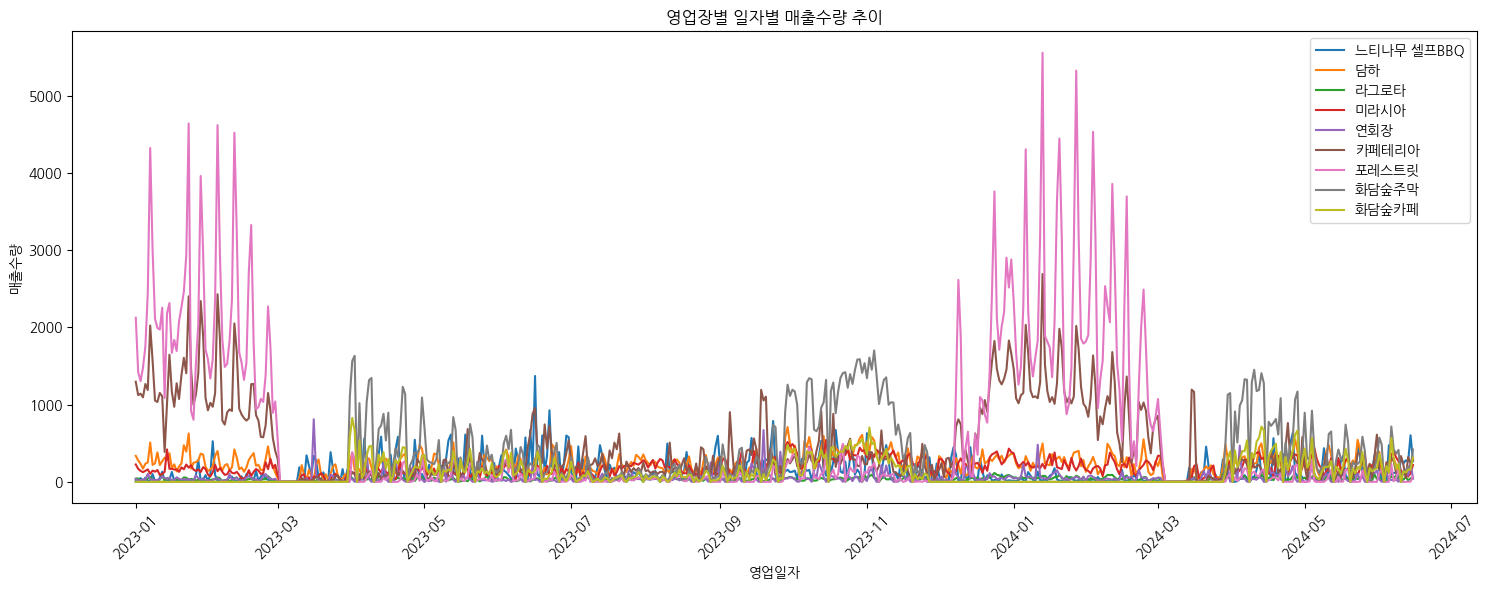

In [ ]:
# ==============================
# 영업장별 일자별 매출수량 추이
# ==============================
grouped = train.groupby(['영업장명', '영업일자'])['매출수량'].sum().reset_index()
plt.figure(figsize=(15, 6))

for name, group in grouped.groupby('영업장명'):
  plt.plot(group['영업일자'], group['매출수량'], label=name)

plt.xlabel('영업일자')
plt.ylabel('매출수량')
plt.title('영업장별 일자별 매출수량 추이')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 영업장별 매출수량 변화 패턴 다름

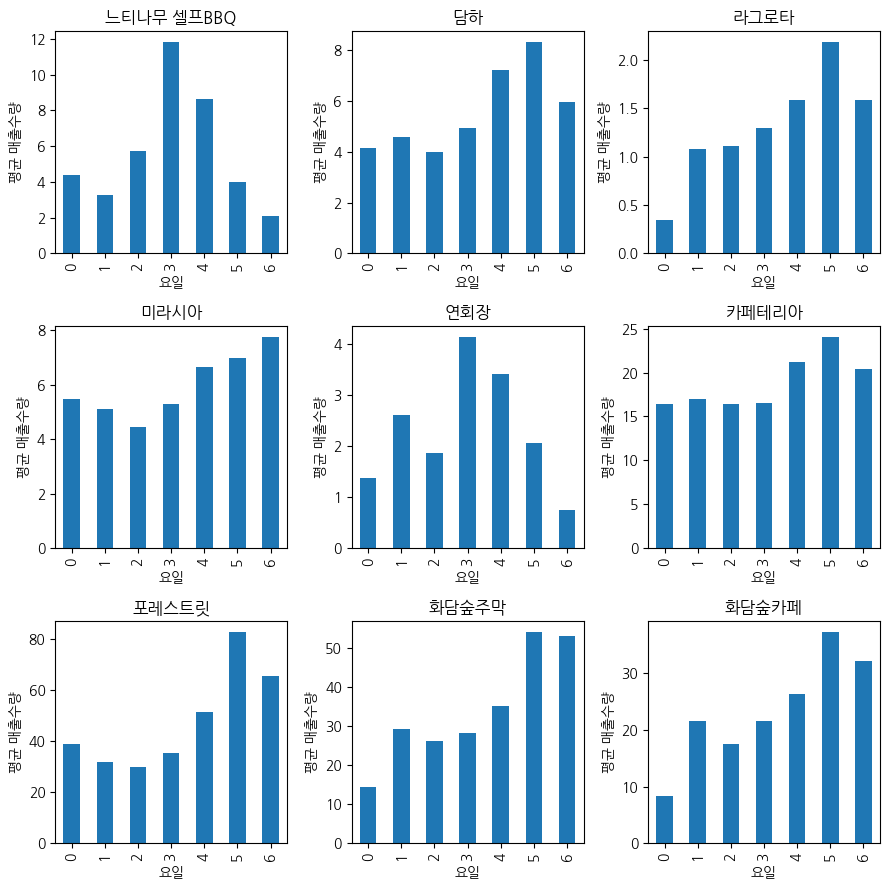

In [ ]:
# =================
# 요일별 평균 매출
# =================
train['영업일자'] = pd.to_datetime(train['영업일자'])
train['년도'] = train['영업일자'].dt.year
train['월'] = train['영업일자'].dt.month
train['일'] = train['영업일자'].dt.day
train['요일'] = train['영업일자'].dt.dayofweek  # 월~일 / 0~6

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for i, store_name in enumerate(train['영업장명'].unique()):
    dfdf = train[train['영업장명'] == store_name]
    dfdf.groupby('요일')['매출수량'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{store_name}')
    axes[i].set_xlabel('요일')
    axes[i].set_ylabel('평균 매출수량')

plt.tight_layout()
plt.show()
# 느티나무, 연회장 목/금 매출량 증가
# 나머지 토/일 매출량 증가

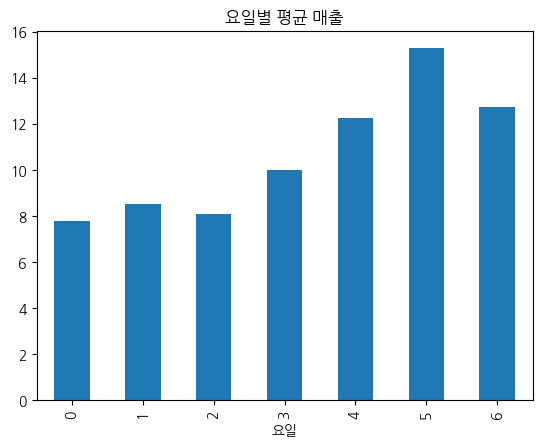

In [ ]:
# =================
# 요일별 평균 매출
# =================
train['영업일자'] = pd.to_datetime(train['영업일자'])
train['요일'] = train['영업일자'].dt.dayofweek  # 월~일 / 0~6

train.groupby('요일')['매출수량'].mean().plot(kind='bar', title='요일별 평균 매출')
plt.show()

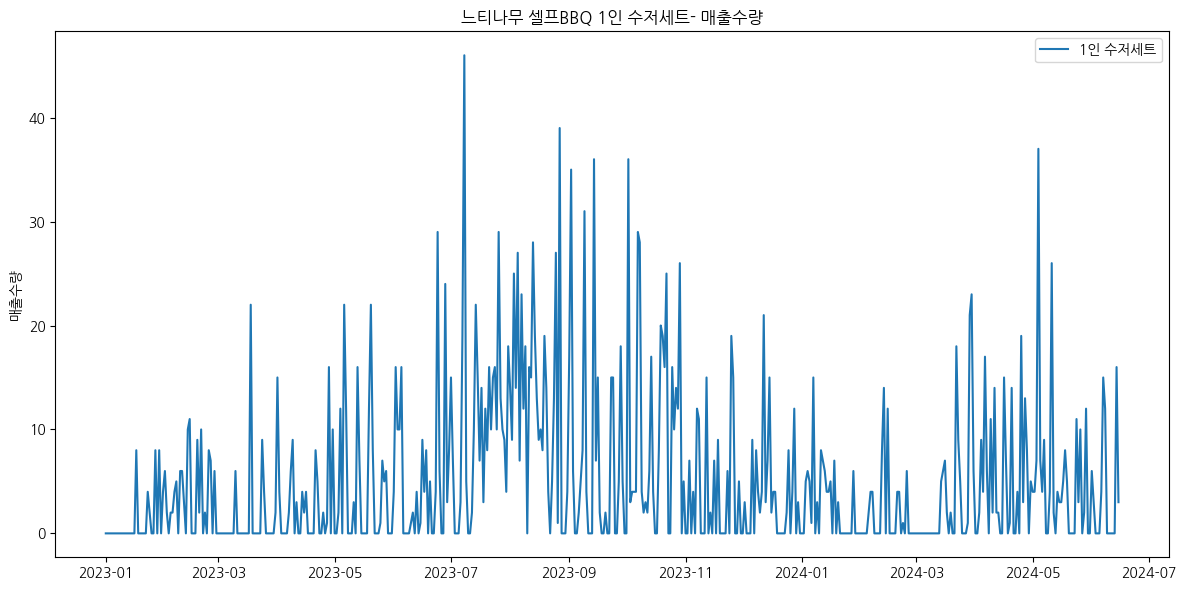

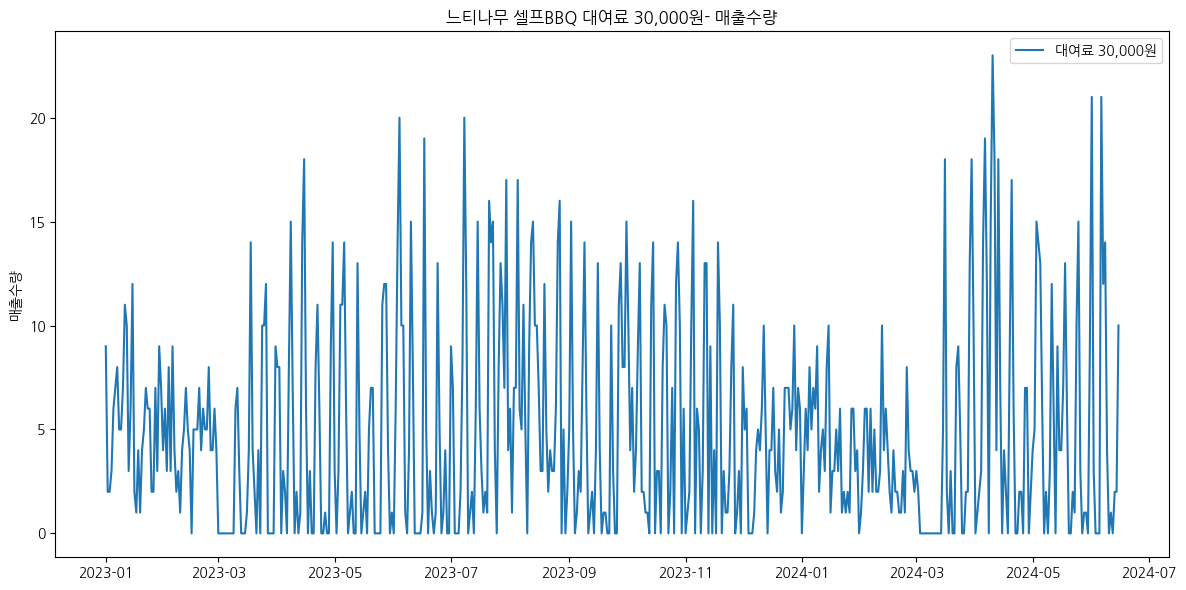

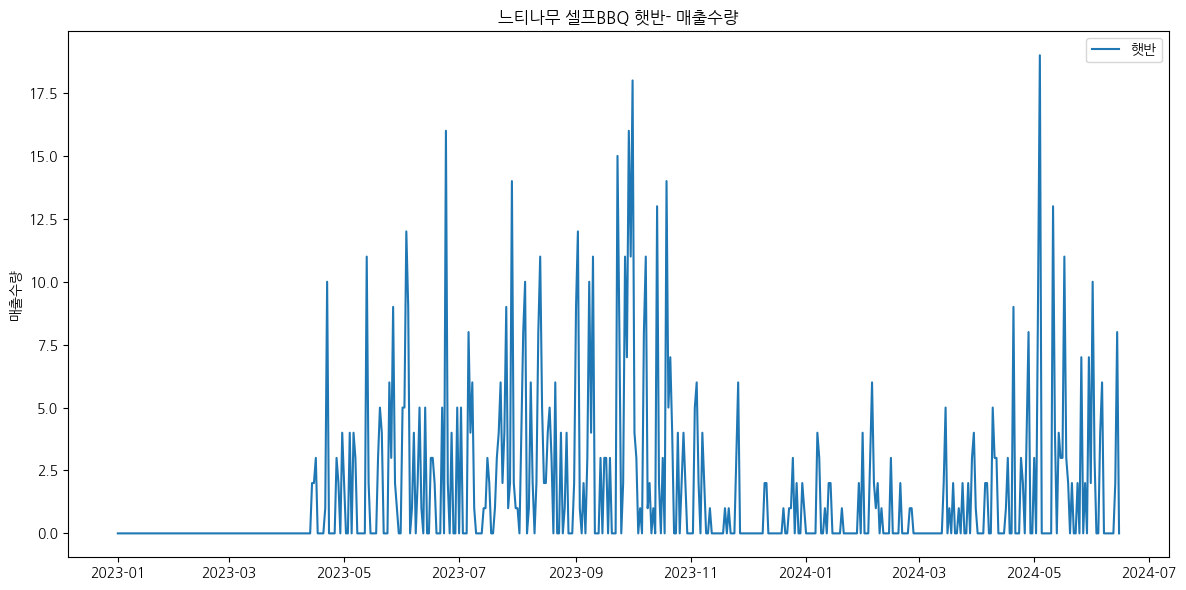

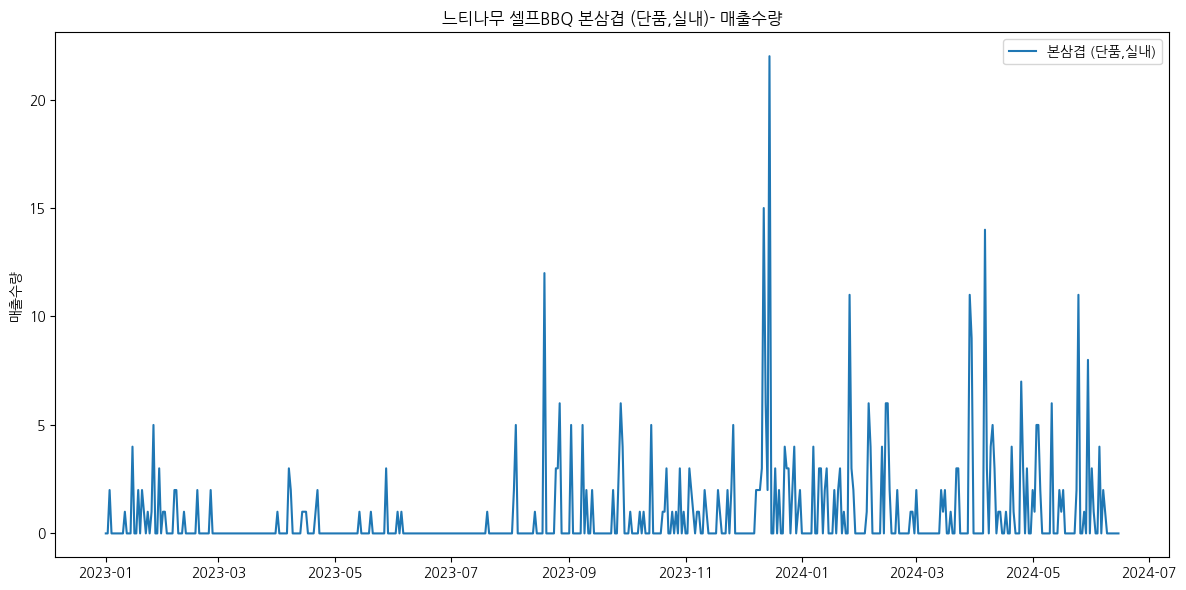

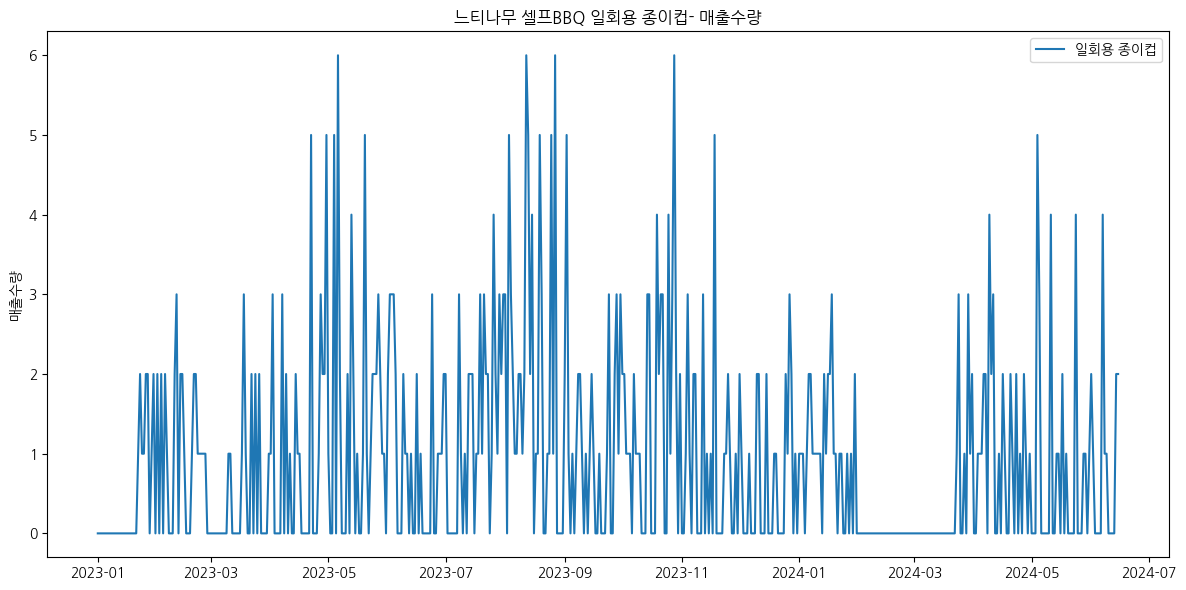

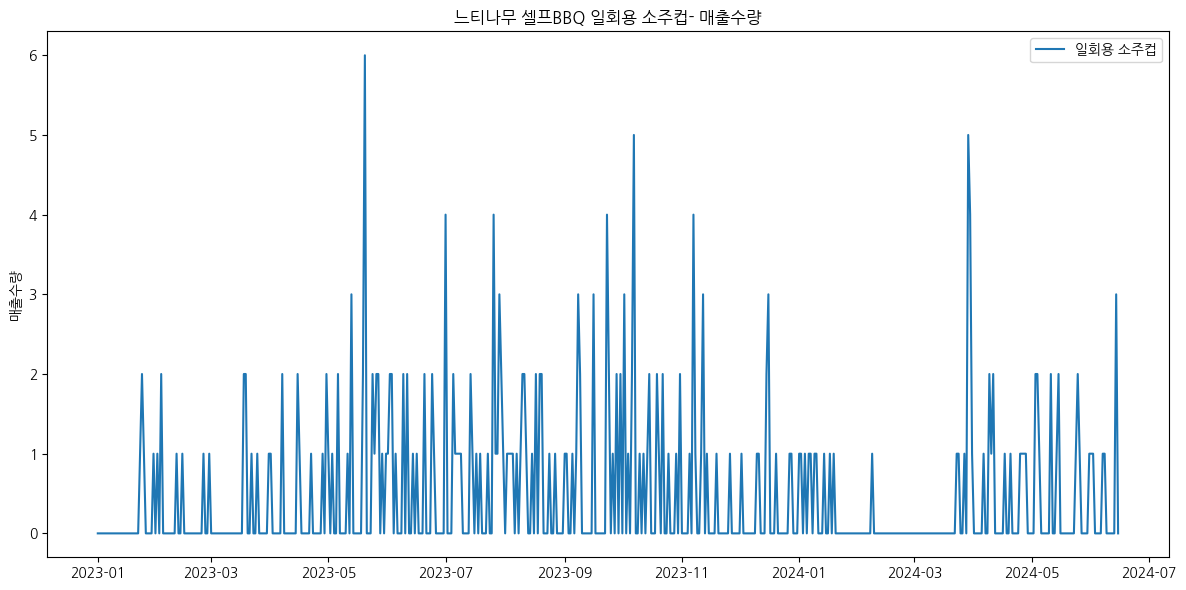

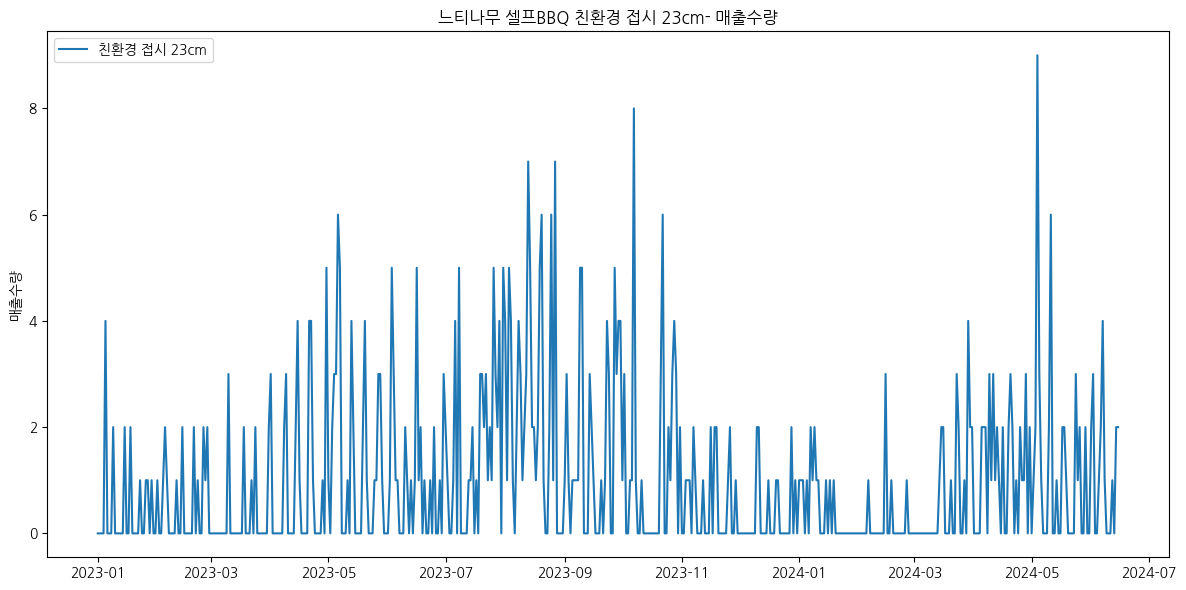

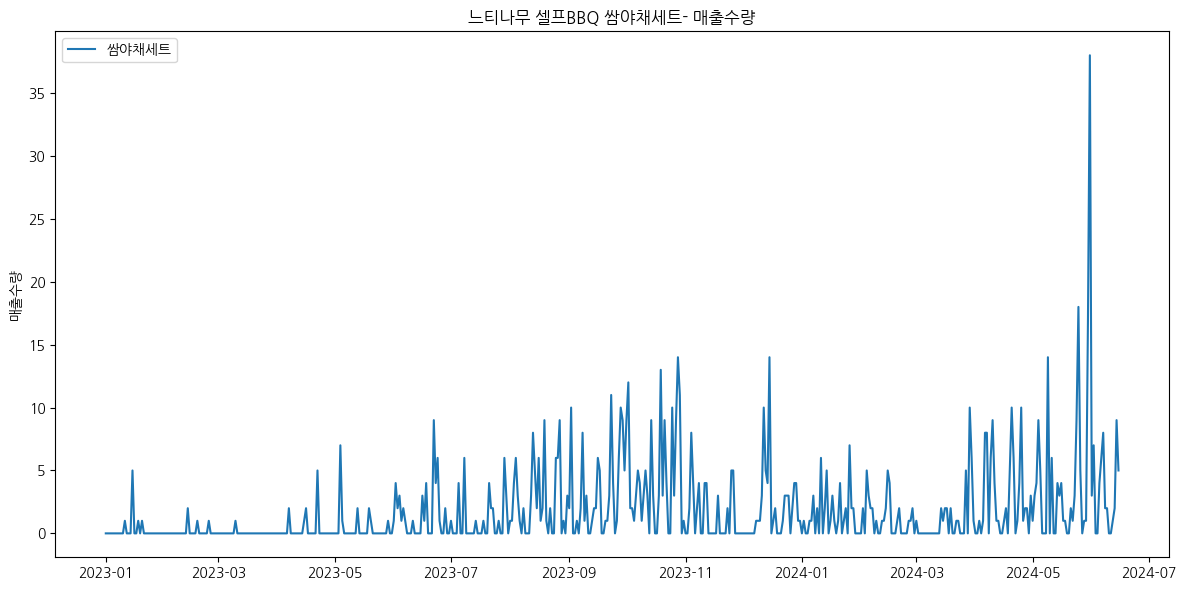

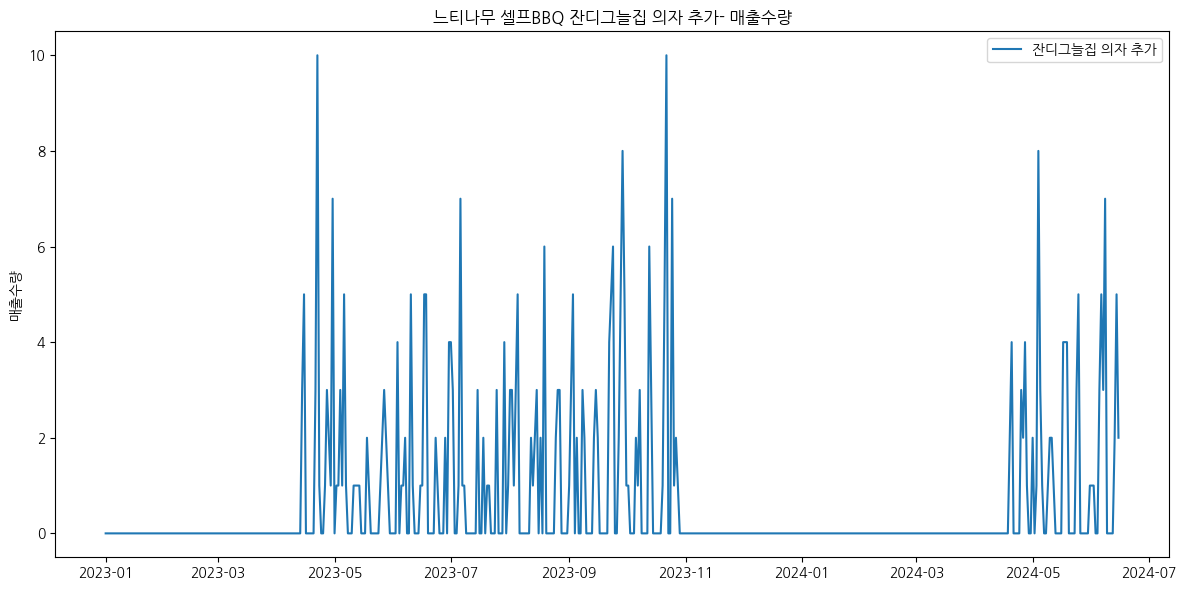

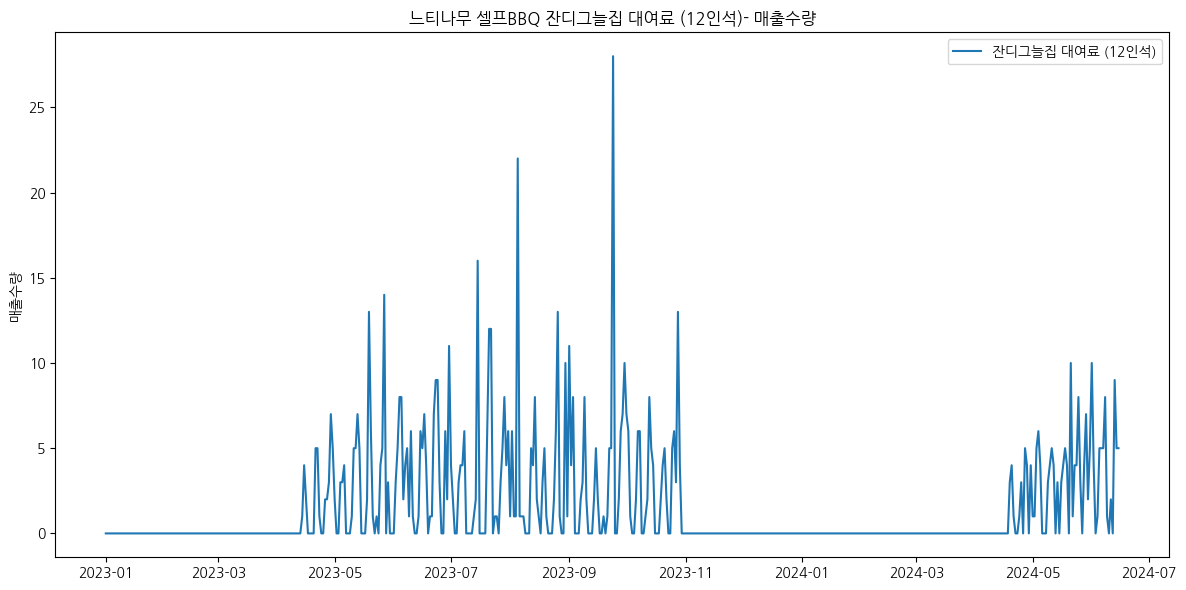

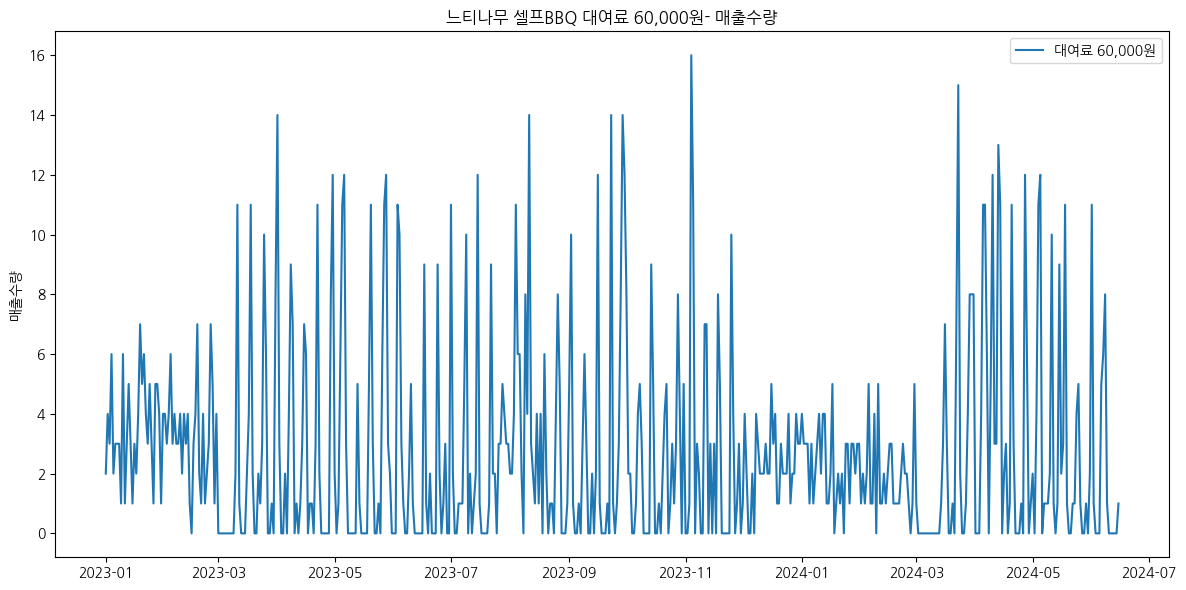

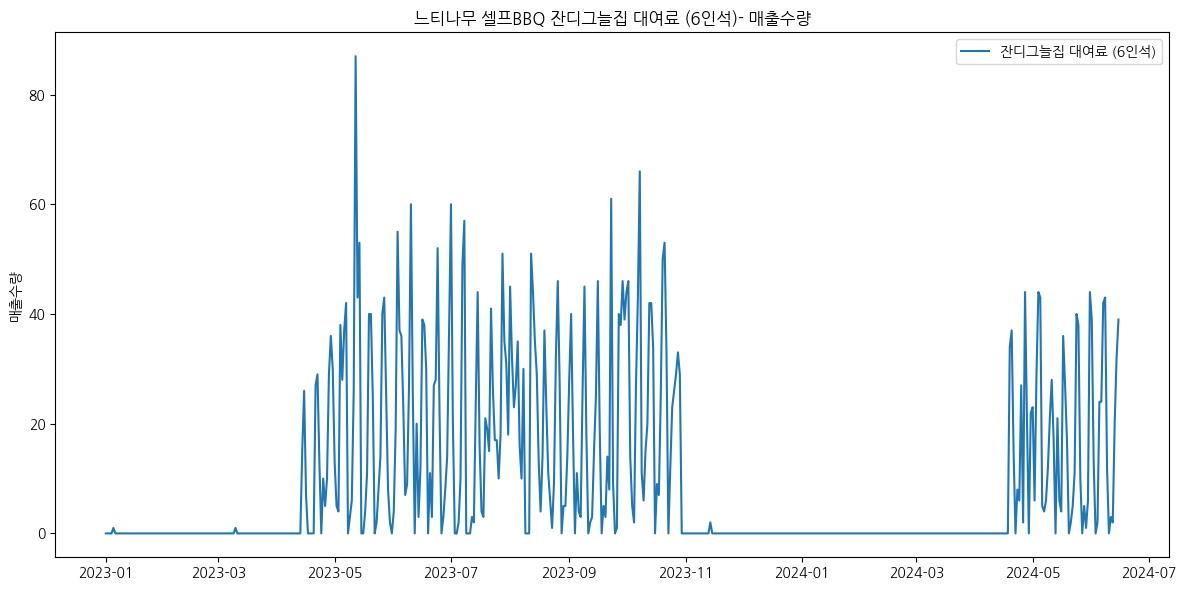

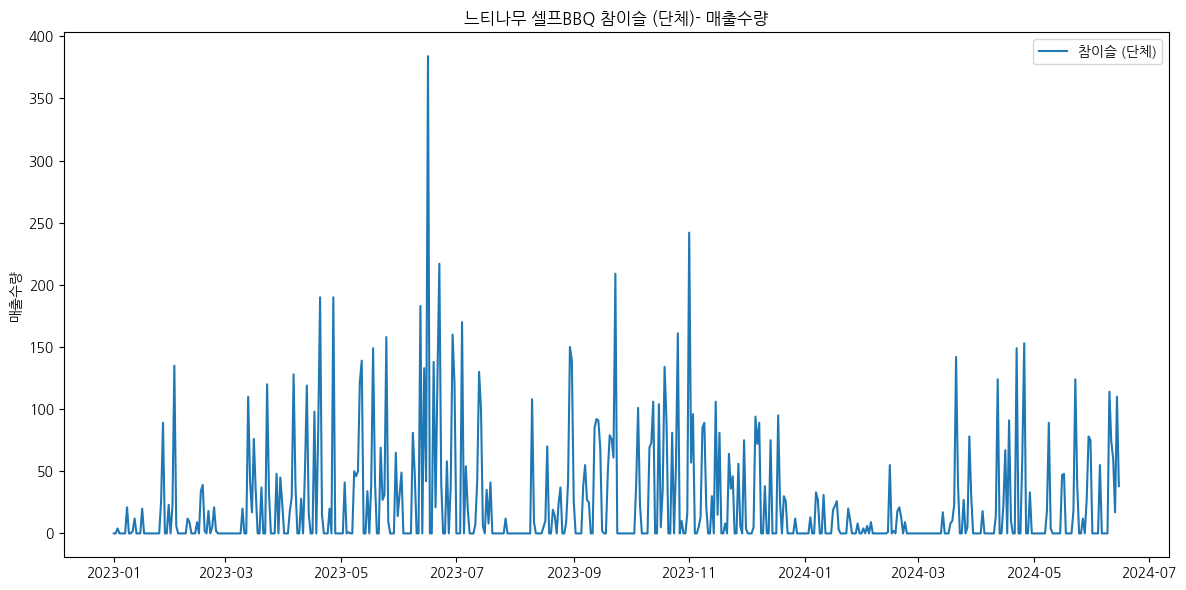

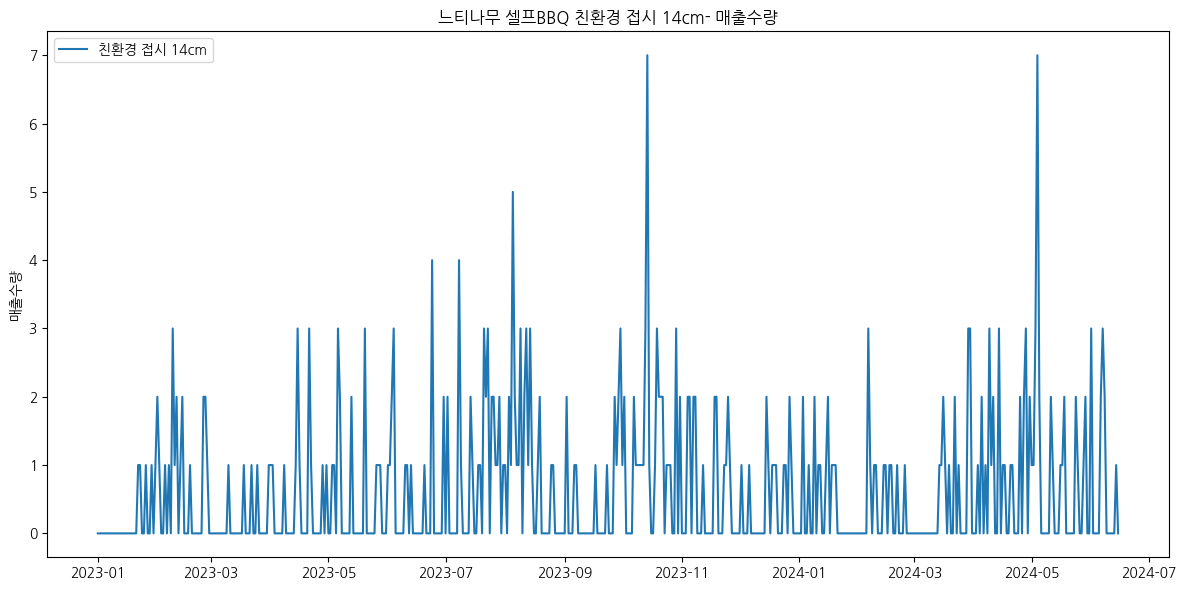

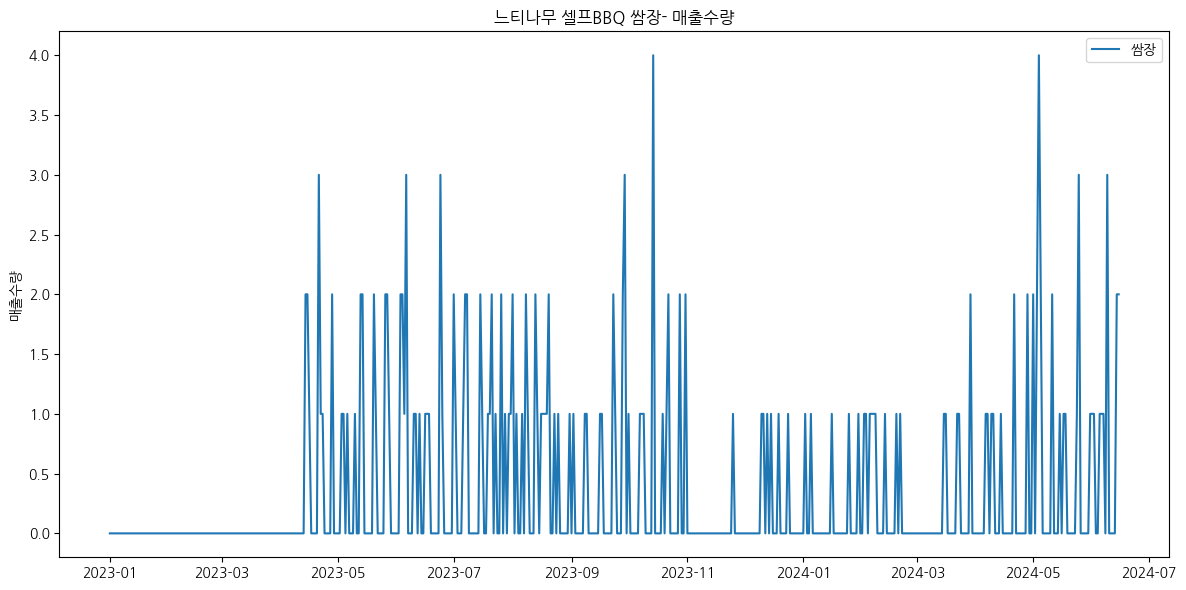

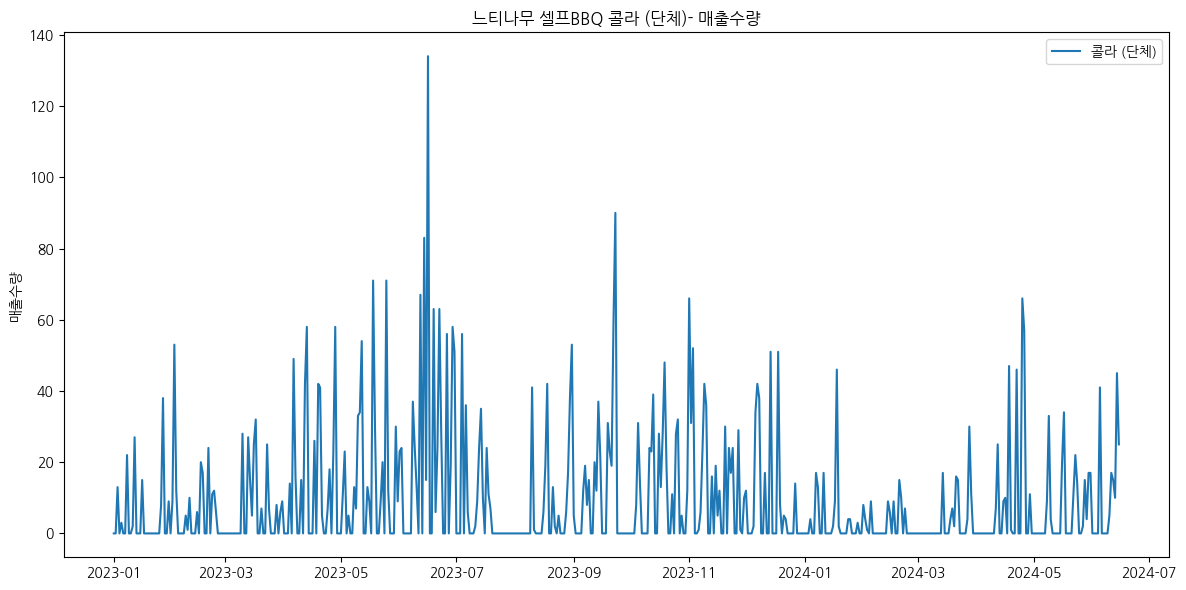

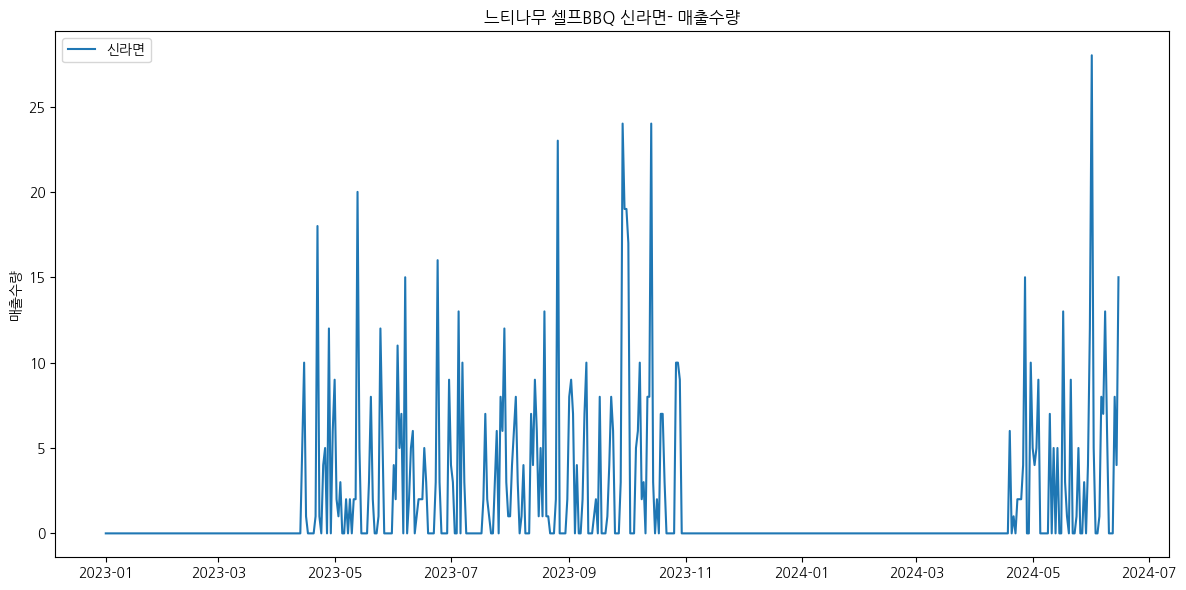

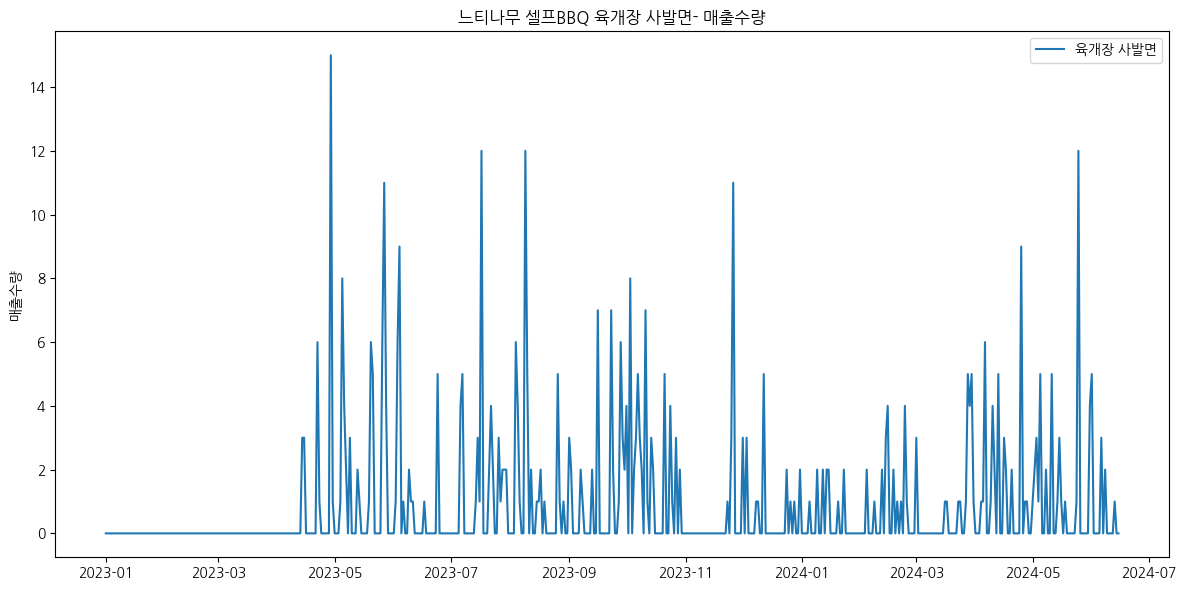

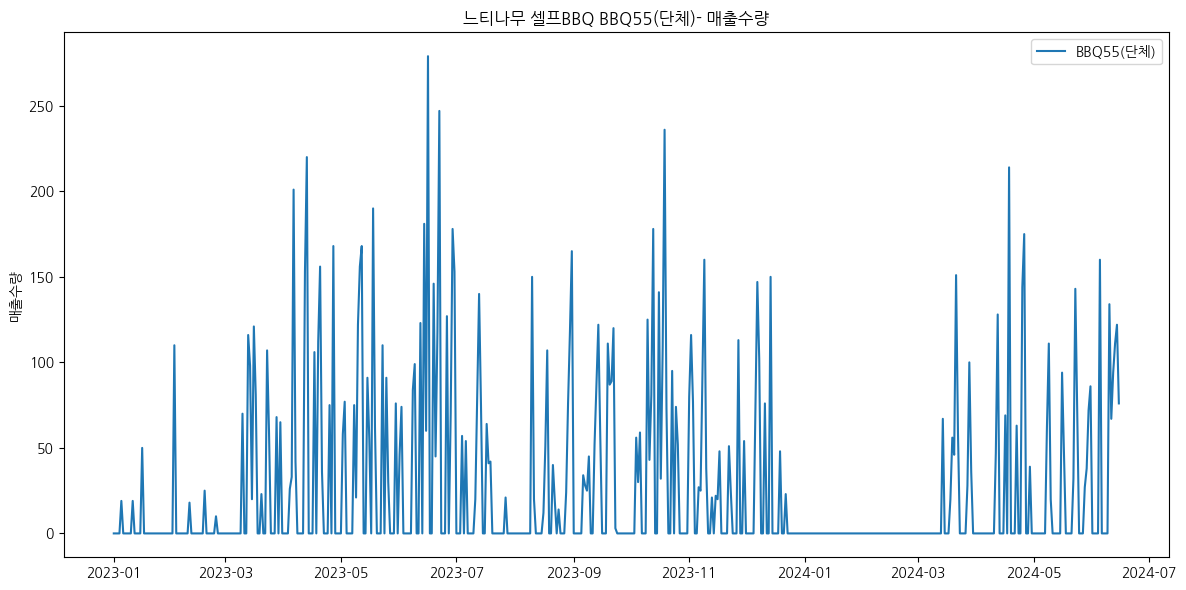

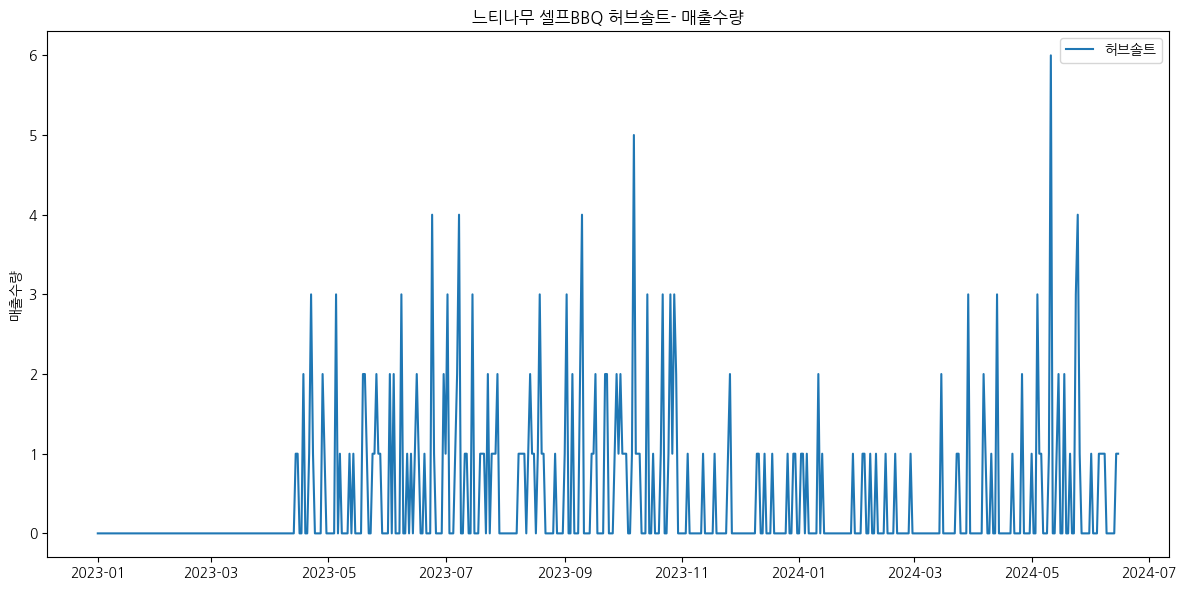

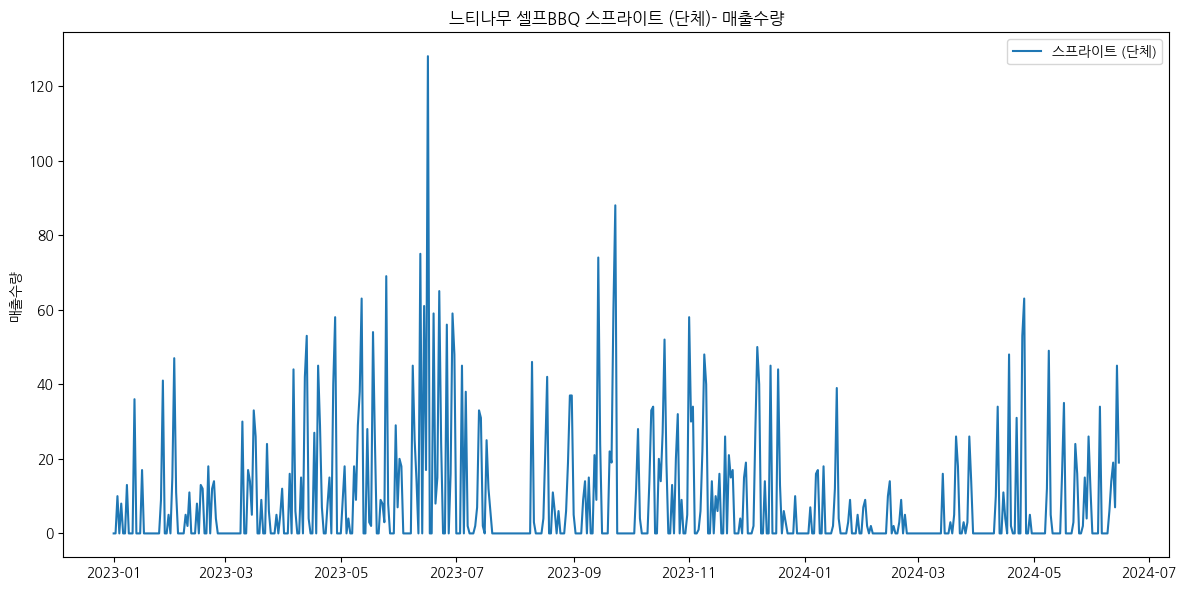

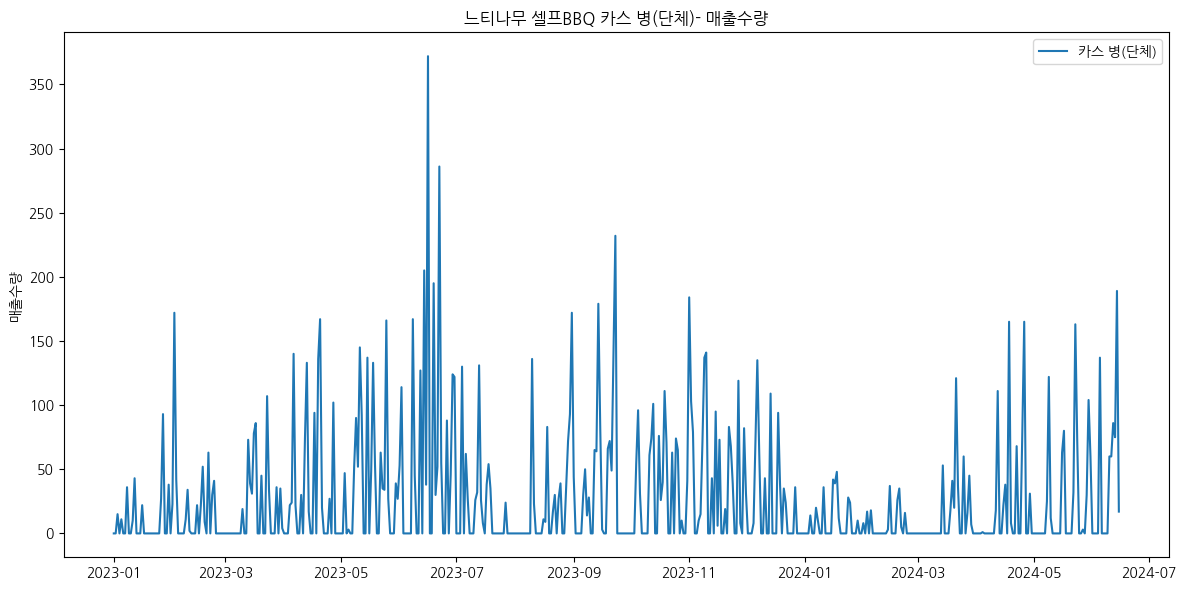

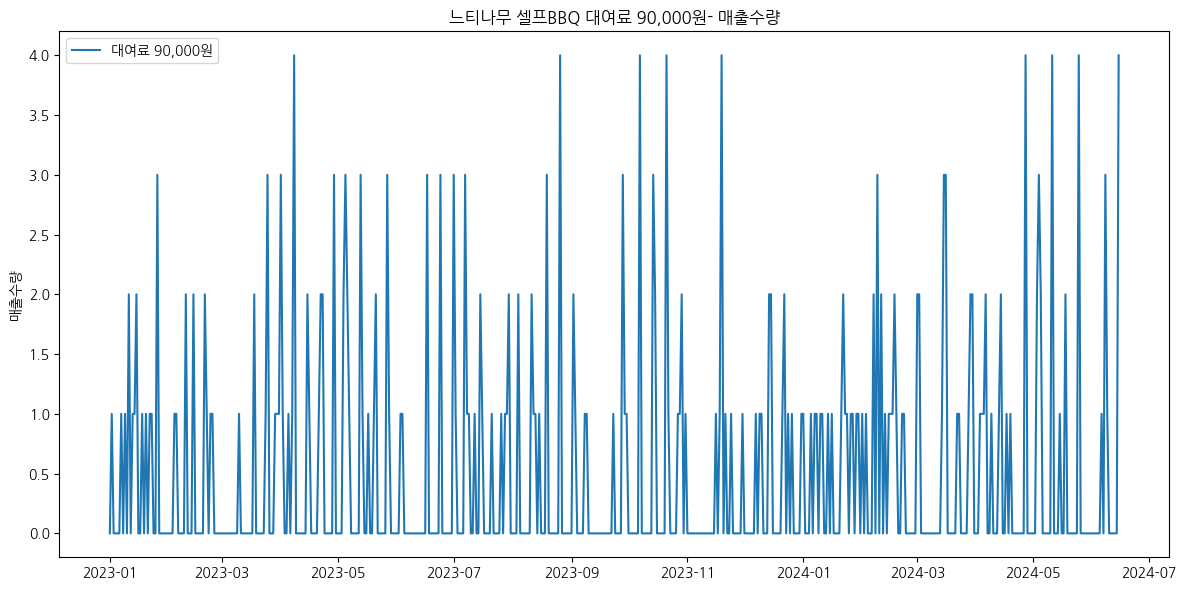

In [ ]:
# ====================================
# 시간 흐름에 따른 메뉴별 매출수량
# ====================================

def vis(df, bnums):
    df2 = df[df['영업장명'] == bnums].sort_values(by='영업일자').reset_index(drop=True)

    for i in df2['메뉴명'].unique():
        plt.figure(figsize=(12, 6))
        temp = df2[df2['메뉴명'] == i]
        x = temp['영업일자']
        y = temp['매출수량']
        plt.plot(x, y, label=i)
        plt.title(f'{bnums} {i}- 매출수량')
        plt.ylabel('매출수량')
        # plt.xlabel('영업일자')
        # plt.xticks(rotation = 45)
        plt.legend()
        plt.tight_layout()
        plt.show()
vis(train,train['영업장명'].unique()[0])

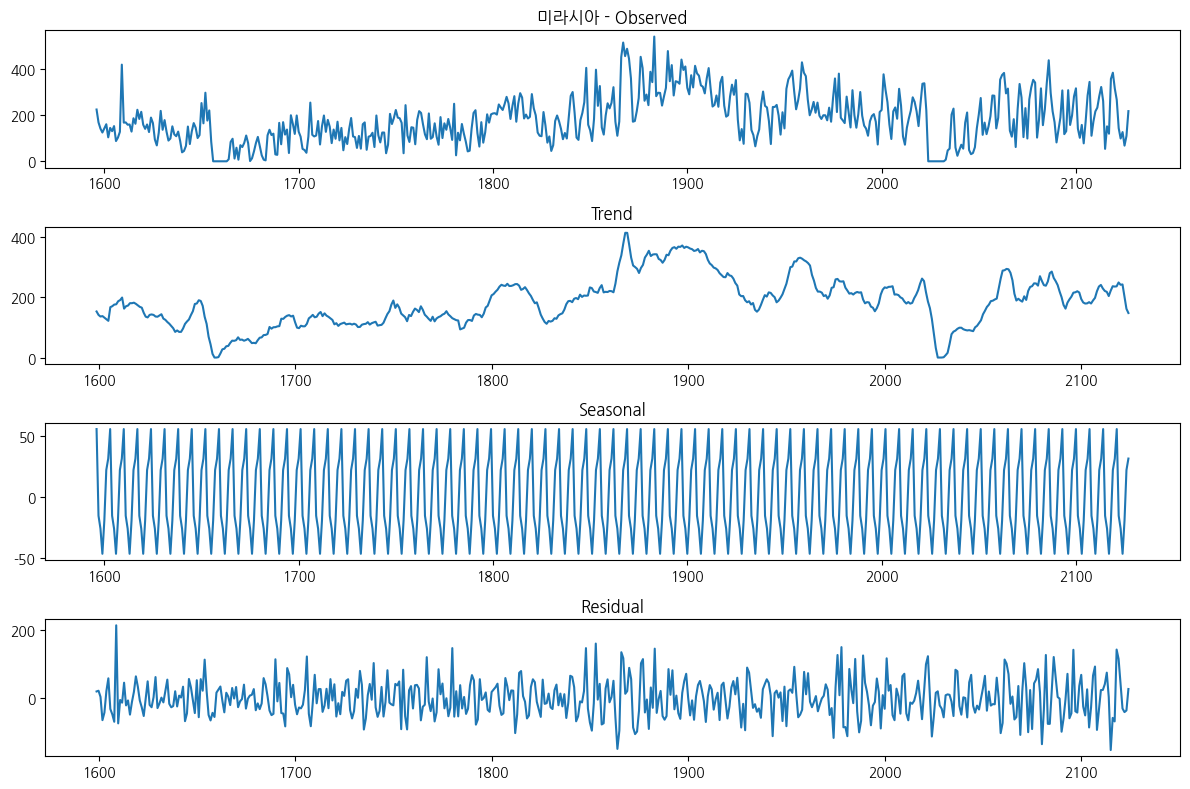

In [ ]:
# ========================
# 추세, 계절성, 잔차 확인
# ========================

from statsmodels.tsa.seasonal import seasonal_decompose
def vis1(df, store):
    df2 = df[df['영업장명_메뉴명'] == store]
    results = seasonal_decompose(df2['매출수량'], period=7)
    fig, axes = plt.subplots(4, 1, figsize=(12, 8))
    components = [results.observed, results.trend, results.seasonal, results.resid]
    titles = ['Observed', 'Trend', 'Seasonal', 'Residual']

    for i, comp in enumerate(components):
        comp_clean = comp.dropna()
        axes[i].plot(comp_clean)
        axes[i].set_title(titles[i])

    plt.tight_layout()
    plt.show()

def vis11(df, store):
    df2 = df[df['영업장명'] == store]
    results = seasonal_decompose(df2['매출수량'], period=7)
    fig, axes = plt.subplots(4, 1, figsize=(12, 8))
    components = [results.observed, results.trend, results.seasonal, results.resid]
    titles = [f'{store} - Observed', 'Trend', 'Seasonal', 'Residual']

    for i, comp in enumerate(components):
        comp_clean = comp.dropna()
        axes[i].plot(comp_clean)
        axes[i].set_title(titles[i])

    plt.tight_layout()
    plt.show()

vis11(grouped,grouped['영업장명'].unique()[3])

In [ ]:
# ========================
# 분포(skewness) 확인
# ========================
from scipy.stats import skew as sk

def skewness(df, y):
  fig = plt.figure(figsize = (20, 50))
  for idx, i in enumerate(df['영업장명_메뉴명'].unique(), 1):
      ax = plt.subplot(15, 15, idx)
      sales = df.loc[df['영업장명_메뉴명'] == i, y].values
      mean = sales.mean().round(3)
      std = sales.std().round(3)
      skew = sk(sales).round(3)
      if skew >= 1.5:
          plt.hist(sales, alpha = 0.7, bins = 50, color = 'red')
      elif skew <= -1.5:
          plt.hist(sales, alpha = 0.7, bins = 50, color = 'blue')
      else:
          plt.hist(sales, alpha = 0.7, bins = 50, color = 'gray')
      plt.title(f'{i}')
      plt.xticks([])
      plt.yticks([])
      plt.xlabel('')
      plt.ylabel('')
      plt.text(0.35, 0.9, f'mean : {mean}',  ha='left', va='center', transform=ax.transAxes)
      plt.text(0.35, 0.8, f'std : {std}',  ha='left', va='center', transform=ax.transAxes)
      plt.text(0.35, 0.7, f'skew : {skew}',  ha='left', va='center', transform=ax.transAxes)

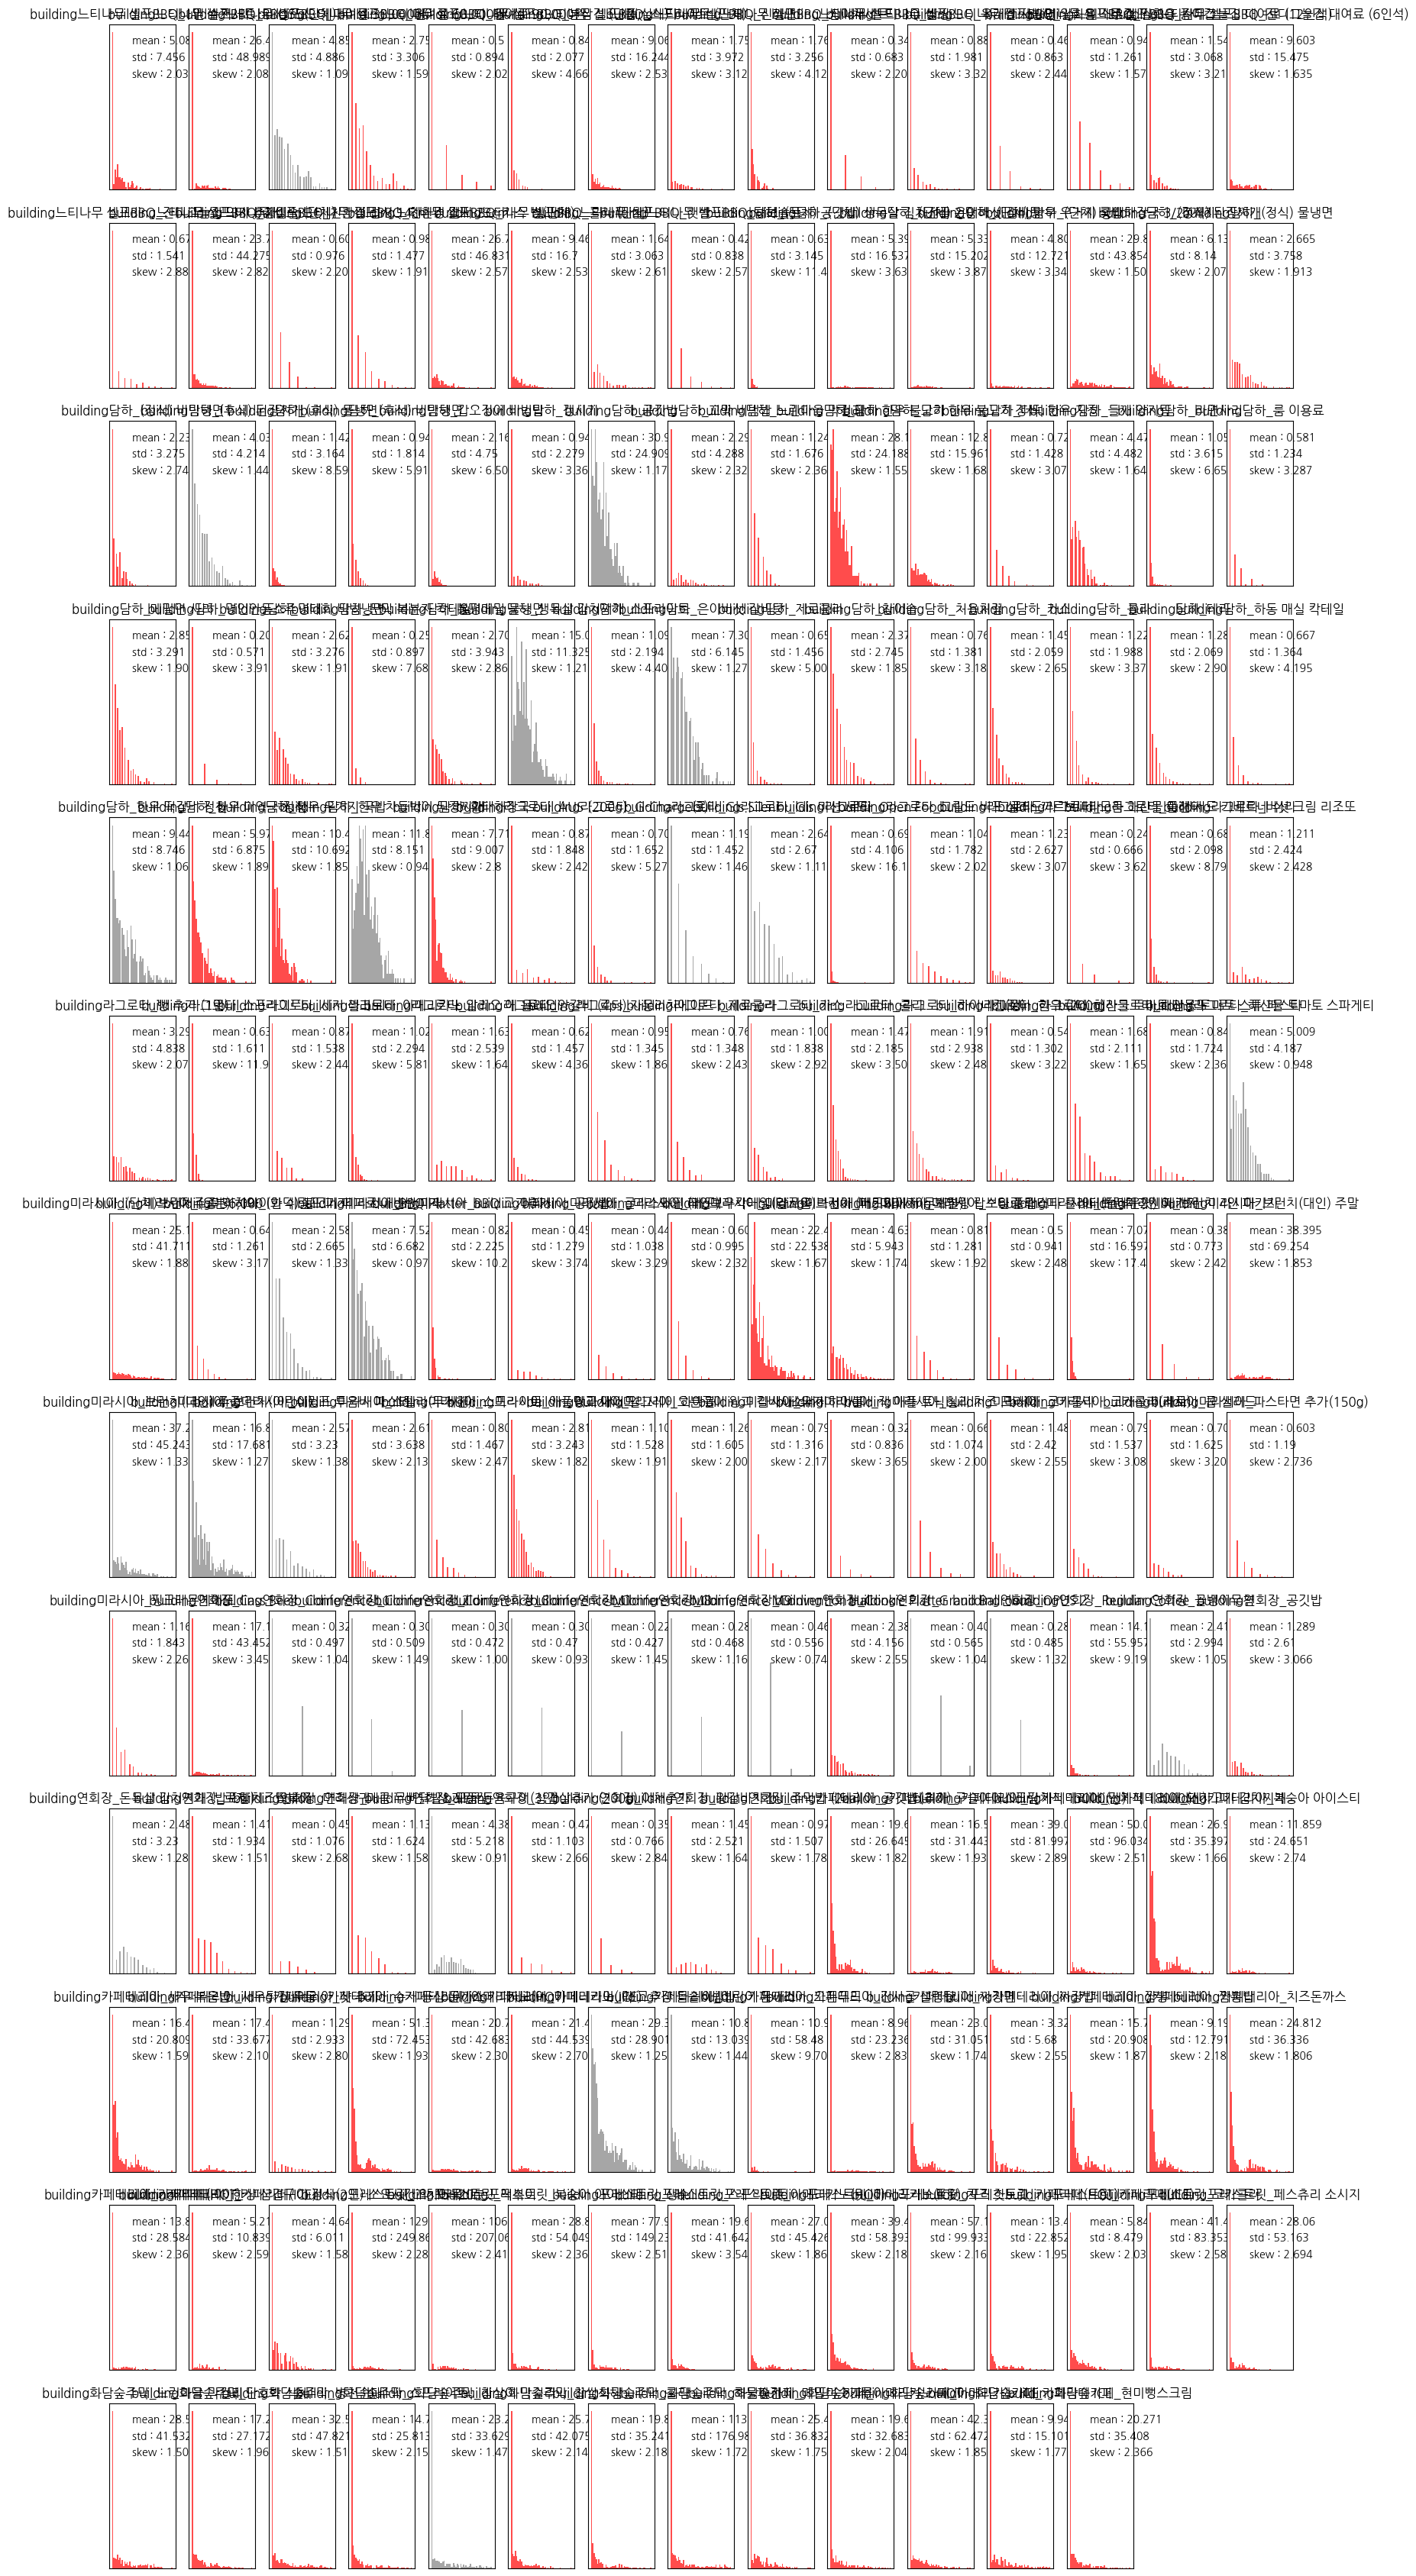

In [ ]:
skewness(train,'매출수량')
# 왼쪽으로 치우친 데이터 많음